In [1]:
# Imports and setup (same as a4, but for CNNs)
from keras.models import Sequential
from keras import layers
from keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random

# Load datasets
(x_train_1, y_train_1), (x_test_1, y_test_1) = tf.keras.datasets.fashion_mnist.load_data()
(x_train_2, y_train_2), (x_test_2, y_test_2) = tf.keras.datasets.mnist.load_data()
(x_train_3, y_train_3), (x_test_3, y_test_3) = tf.keras.datasets.cifar10.load_data()

num_classes = 10
# Reshape for CNN input (add channel axis)
x_train_1 = x_train_1[..., np.newaxis]
x_test_1  = x_test_1[..., np.newaxis]
x_train_2 = x_train_2[..., np.newaxis]
x_test_2  = x_test_2[..., np.newaxis]
# CIFAR-10 is already (N,32,32,3)

# Normalize
x_train_1 = x_train_1.astype('float32') / 255.0
x_test_1  = x_test_1.astype('float32')  / 255.0
x_train_2 = x_train_2.astype('float32') / 255.0
x_test_2  = x_test_2.astype('float32')  / 255.0
x_train_3 = x_train_3.astype('float32') / 255.0
x_test_3  = x_test_3.astype('float32')  / 255.0

# One-hot encode labels
y_train_1 = tf.keras.utils.to_categorical(y_train_1, num_classes)
y_test_1  = tf.keras.utils.to_categorical(y_test_1, num_classes)
y_train_2 = tf.keras.utils.to_categorical(y_train_2, num_classes)
y_test_2  = tf.keras.utils.to_categorical(y_test_2, num_classes)
y_train_3 = y_train_3.reshape(-1) if y_train_3.ndim > 1 else y_train_3
y_test_3  = y_test_3.reshape(-1)  if y_test_3.ndim > 1 else y_test_3
y_train_3 = tf.keras.utils.to_categorical(y_train_3, num_classes)
y_test_3  = tf.keras.utils.to_categorical(y_test_3, num_classes)

# Print shapes for verification
print('fashion mnist | train: ', x_train_1.shape, y_train_1.shape, ' | test: ', x_test_1.shape, y_test_1.shape)
print('digit mnist | train: ', x_train_2.shape, y_train_2.shape, ' | test: ', x_test_2.shape, y_test_2.shape)
print('cipher 10 | train: ', x_train_3.shape, y_train_3.shape, ' | test: ', x_test_3.shape, y_test_3.shape)

# Label lists
fashion_labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']
mnist_labels = [str(i) for i in range(10)]
cifar_labels = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

2025-11-02 15:10:48.856722: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 15:10:48.857317: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-02 15:10:49.422084: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 15:10:51.931800: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

fashion mnist | train:  (60000, 28, 28, 1) (60000, 10)  | test:  (10000, 28, 28, 1) (10000, 10)
digit mnist | train:  (60000, 28, 28, 1) (60000, 10)  | test:  (10000, 28, 28, 1) (10000, 10)
cipher 10 | train:  (50000, 32, 32, 3) (50000, 10)  | test:  (10000, 32, 32, 3) (10000, 10)


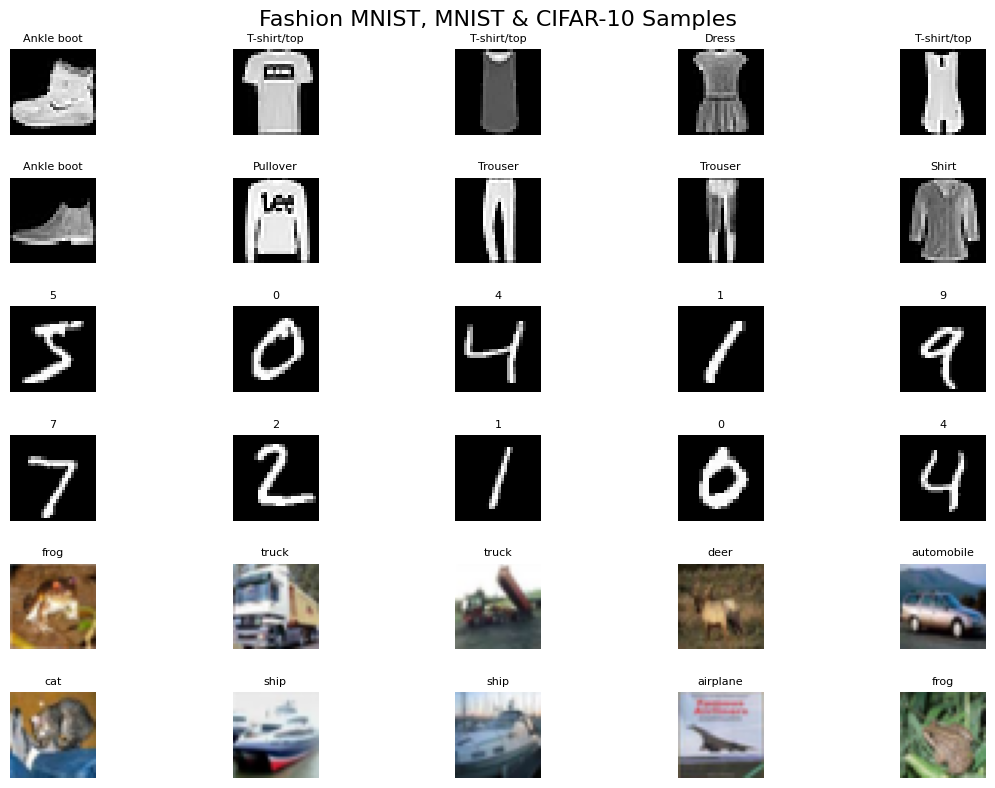

In [2]:
# Visualize samples (same as a4)
fig, axes = plt.subplots(6, 5, figsize=(12, 8))
fig.suptitle("Fashion MNIST, MNIST & CIFAR-10 Samples", fontsize=16)
datasets = [
    ("Fashion MNIST - Train", x_train_1, y_train_1, fashion_labels, 'gray'),
    ("Fashion MNIST - Test", x_test_1, y_test_1, fashion_labels, 'gray'),
    ("MNIST - Train", x_train_2, y_train_2, mnist_labels, 'gray'),
    ("MNIST - Test", x_test_2, y_test_2, mnist_labels, 'gray'),
    ("CIFAR-10 - Train", x_train_3, y_train_3, cifar_labels, None),
    ("CIFAR-10 - Test", x_test_3, y_test_3, cifar_labels, None),
]
for row, (title, x_data, y_data, labels, cmap) in enumerate(datasets):
    for col in range(5):
        ax = axes[row, col]
        ax.axis("off")
        img = x_data[col]
        if img.shape[-1] == 1:
            img = img.squeeze(-1)
        if cmap:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(img)
        if y_data.ndim > 1 and getattr(y_data, 'shape', None) and y_data.shape[1] > 1:
            label_idx = np.argmax(y_data[col])
        else:
            label_idx = y_data[col][0] if y_data.ndim > 1 else y_data[col]
        ax.set_title(labels[int(label_idx)], fontsize=8)
    axes[row, 0].set_ylabel(title, fontsize=10, rotation=0, labelpad=50, va='center')
plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.5)
plt.show()

In [3]:
# Fashion MNIST CNN model
model1 = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model1.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/home/zahin/Desktop/AI_LAB/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-02 15:11:13.129315: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,778 (4.58 MB)

 Trainable params: 1,200,330 (4.58 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
# Train model1 on Fashion MNIST
history1 = model1.fit(
    x_train_1, y_train_1,
    validation_data=(x_test_1, y_test_1),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.8447 - loss: 0.4453 - val_accuracy: 0.8872 - val_loss: 0.3129
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.8447 - loss: 0.4453 - val_accuracy: 0.8872 - val_loss: 0.3129
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8923 - loss: 0.3030 - val_accuracy: 0.9011 - val_loss: 0.2828
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8923 - loss: 0.3030 - val_accuracy: 0.9011 - val_loss: 0.2828
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9053 - loss: 0.2645 - val_accuracy: 0.9122 - val_loss: 0.2380
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9053 - loss: 0.2645 - val_accuracy: 0.9122 - val_loss: 0.2380
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9141 - loss: 0.2406 - val_accuracy: 0.9194 - val_loss: 0.2230
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9141 -

In [5]:
# MNIST CNN model
model2 = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model2.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,778 (4.58 MB)

 Trainable params: 1,200,330 (4.58 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# Train model2 on MNIST
history2 = model2.fit(
    x_train_2, y_train_2,
    validation_data=(x_test_2, y_test_2),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9526 - loss: 0.1588 - val_accuracy: 0.9828 - val_loss: 0.0520
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9526 - loss: 0.1588 - val_accuracy: 0.9828 - val_loss: 0.0520
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9766 - loss: 0.0778 - val_accuracy: 0.9886 - val_loss: 0.0333
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9766 - loss: 0.0778 - val_accuracy: 0.9886 - val_loss: 0.0333
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9818 - loss: 0.0608 - val_accuracy: 0.9865 - val_loss: 0.0379
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9818 - loss: 0.0608 - val_accuracy: 0.9865 - val_loss: 0.0379
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.9842 - loss: 0.0520 - val_accuracy: 0.9886 - val_loss: 0.0344
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.9842 -

In [7]:
# CIFAR-10 CNN model
model3 = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model3.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,642 (4.87 MB)

 Trainable params: 1,276,682 (4.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# Train model3 on CIFAR-10
history3 = model3.fit(
    x_train_3, y_train_3,
    validation_data=(x_test_3, y_test_3),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 60ms/step - accuracy: 0.5192 - loss: 1.4217 - val_accuracy: 0.5142 - val_loss: 1.5603
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 60ms/step - accuracy: 0.5192 - loss: 1.4217 - val_accuracy: 0.5142 - val_loss: 1.5603
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6540 - loss: 0.9881 - val_accuracy: 0.5912 - val_loss: 1.1610
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6540 - loss: 0.9881 - val_accuracy: 0.5912 - val_loss: 1.1610
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.6917 - loss: 0.8861 - val_accuracy: 0.6568 - val_loss: 1.0352
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.6917 - loss: 0.8861 - val_accuracy: 0.6568 - val_loss: 1.0352
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.7191 - loss: 0.8102 - val_accuracy: 0.6436 - val_loss: 1.1543
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.7191

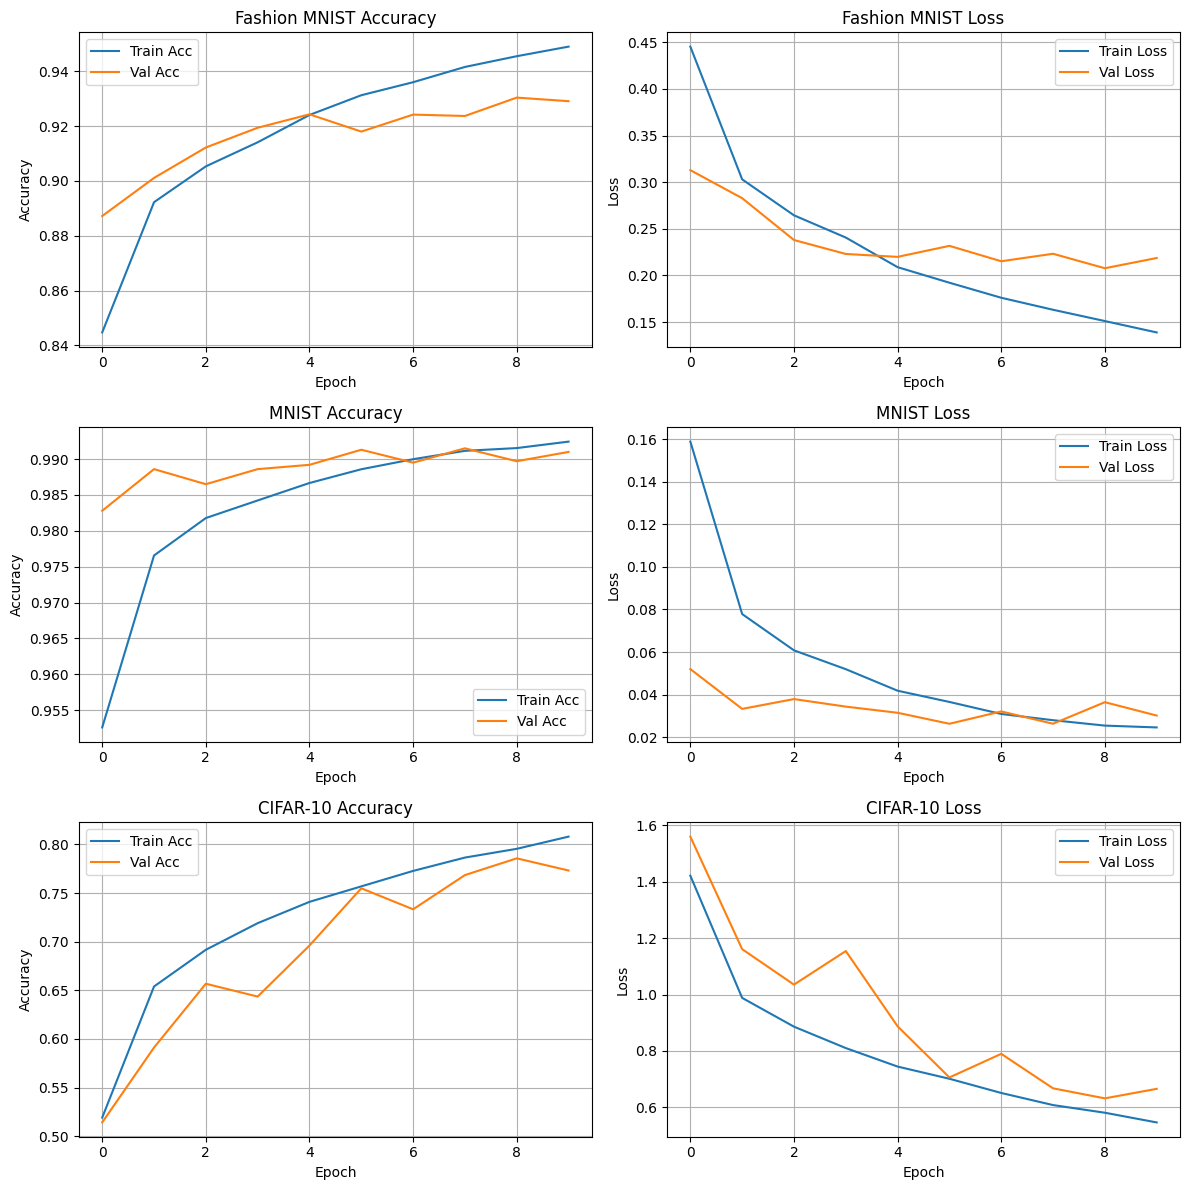

In [9]:
# Plotting function for accuracy and loss (same as a4, adapted for CNN histories)
def plot_all_histories(histories, titles):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    for i, (history, title) in enumerate(zip(histories, titles)):
        axes[i, 0].plot(history.history['accuracy'], label='Train Acc')
        axes[i, 0].plot(history.history['val_accuracy'], label='Val Acc')
        axes[i, 0].set_title(f"{title} Accuracy")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Accuracy")
        axes[i, 0].legend()
        axes[i, 0].grid(True)
        axes[i, 1].plot(history.history['loss'], label='Train Loss')
        axes[i, 1].plot(history.history['val_loss'], label='Val Loss')
        axes[i, 1].set_title(f"{title} Loss")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("Loss")
        axes[i, 1].legend()
        axes[i, 1].grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_all_histories([history1, history2, history3], ["Fashion MNIST", "MNIST", "CIFAR-10"])

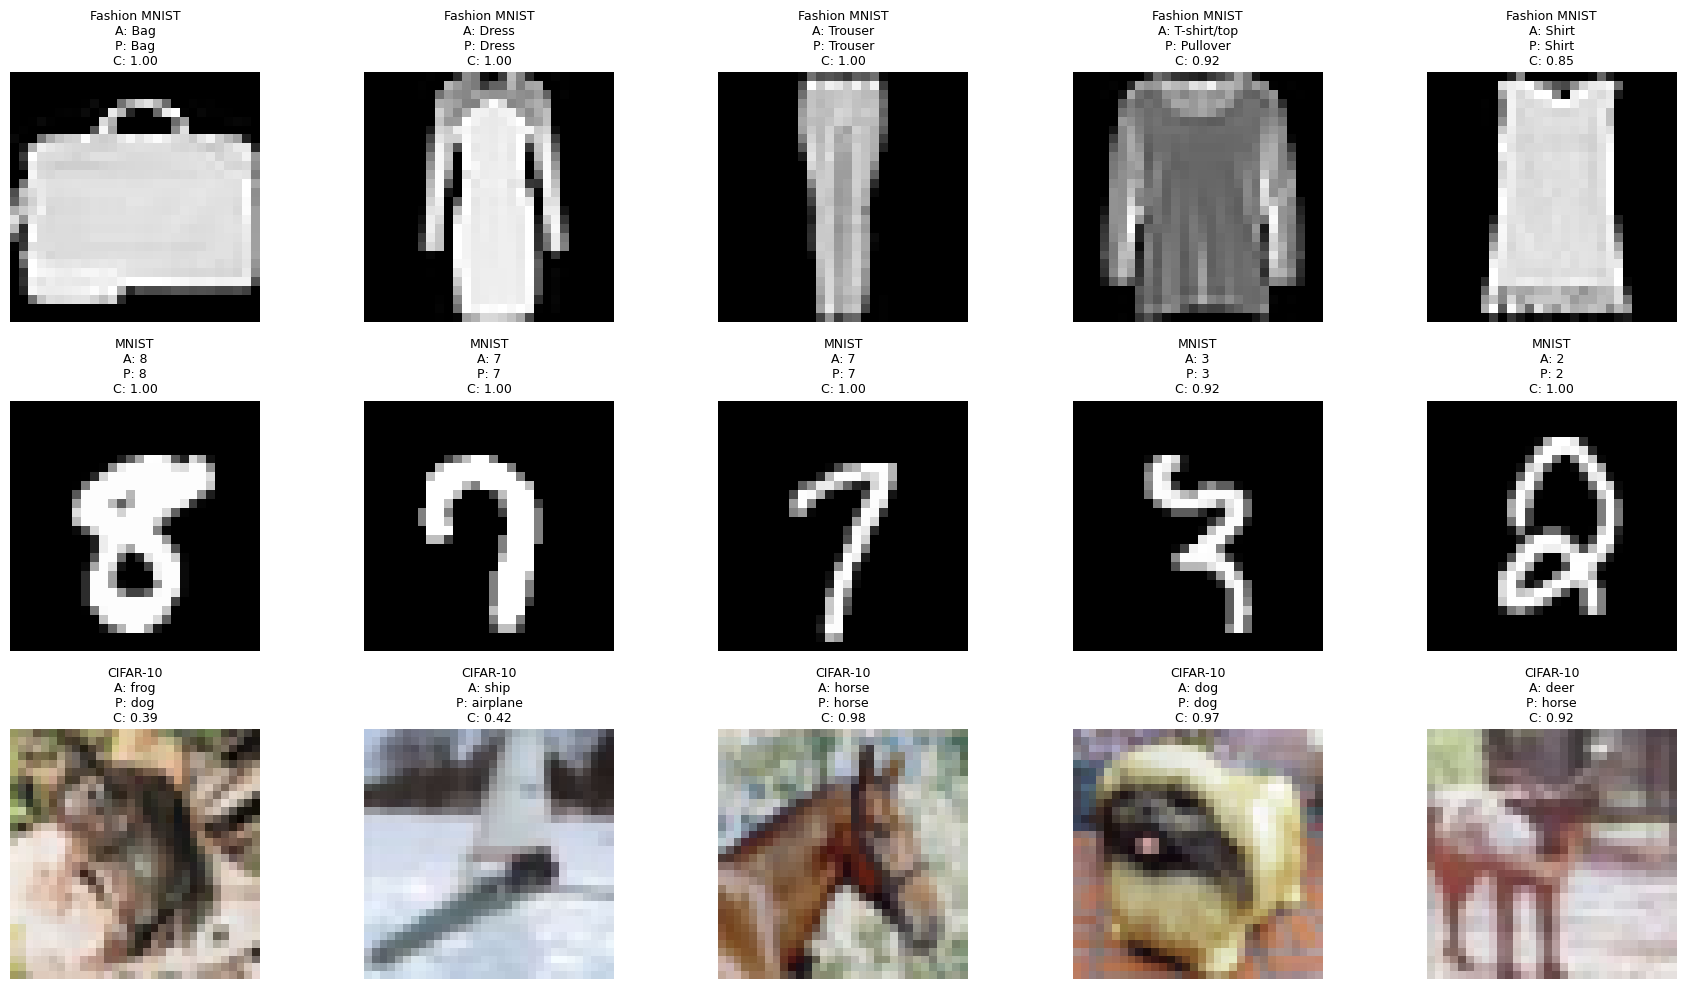

In [10]:
# Function to plot 5 random predictions for each model with confidence
def plot_random_predictions(models, x_tests, y_tests, label_lists, titles):
    import random
    fig, axes = plt.subplots(3, 5, figsize=(18, 10))
    for row, (model, x_test, y_test, labels, title) in enumerate(zip(models, x_tests, y_tests, label_lists, titles)):
        idxs = random.sample(range(x_test.shape[0]), 5)
        preds = model.predict(x_test[idxs], verbose=0)
        for col, (i, pred) in enumerate(zip(idxs, preds)):
            ax = axes[row, col]
            actual_idx = np.argmax(y_test[i])
            pred_idx = np.argmax(pred)
            confidence = np.max(pred)
            img = x_test[i]
            if img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze(-1)
            if img.ndim == 2:
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"{title}\nA: {labels[actual_idx]}\nP: {labels[pred_idx]}\nC: {confidence:.2f}", fontsize=9)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_random_predictions(
    [model1, model2, model3],
    [x_test_1, x_test_2, x_test_3],
    [y_test_1, y_test_2, y_test_3],
    [fashion_labels, mnist_labels, cifar_labels],
    ["Fashion MNIST", "MNIST", "CIFAR-10"]
)